# RQ5: Sensitivity to Evaluation Metrics

This notebook is designed for Kaggle. It auto-detects the raw CSV/XLSX input file, performs preprocessing, generates the research-question-specific table(s), and saves the figure(s) as PDF.

In [3]:

import os, glob, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.dummy import DummyClassifier

plt.style.use("default")
plt.rcParams.update({
    "figure.dpi": 180,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9
})

OUTPUT_DIR = "/kaggle/working"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def find_input_file():
    search_roots = ["/kaggle/input", "/mnt/data", "."]
    candidates = []
    for root in search_roots:
        if os.path.exists(root):
            for ext in ("*.csv", "*.xlsx", "*.xls"):
                candidates.extend(glob.glob(os.path.join(root, "**", ext), recursive=True))
    if not candidates:
        raise FileNotFoundError("No CSV/XLSX file found in Kaggle input or local folders.")
    # Prefer the largest likely dataset file and files that look like the requested dataset.
    candidates = list(dict.fromkeys(candidates))
    scored = []
    for p in candidates:
        name = os.path.basename(p).lower()
        score = 0
        if "shopper" in name or "e-commerce" in name or "amazonshopify" in name:
            score += 100
        if name.endswith(".csv"):
            score += 10
        try:
            score += min(os.path.getsize(p) / 1_000_000, 50)
        except OSError:
            pass
        scored.append((score, p))
    scored.sort(reverse=True)
    return scored[0][1]

def load_data():
    path = find_input_file()
    print("Using input file:", path)
    if path.lower().endswith(".csv"):
        df = pd.read_csv(path)
    else:
        df = pd.read_excel(path)
    return df, path

def engineer_features(df):
    df = df.copy()
    if "user_id" in df.columns:
        df = df.drop(columns=["user_id"])
    if "last_purchase_date" in df.columns:
        dt = pd.to_datetime(df["last_purchase_date"], errors="coerce")
        ref = dt.max()
        if pd.notna(ref):
            df["days_since_last_purchase"] = (ref - dt).dt.days
        else:
            df["days_since_last_purchase"] = np.nan
        df = df.drop(columns=["last_purchase_date"])
    # Convert target to integer if present.
    if "premium_subscription" in df.columns:
        df["premium_subscription"] = pd.to_numeric(df["premium_subscription"], errors="coerce").fillna(0).astype(int)
    # Boolean-like columns to ints if any
    for c in df.columns:
        if df[c].dtype == bool:
            df[c] = df[c].astype(int)
    return df

def split_xy(df, target="premium_subscription"):
    if target not in df.columns:
        raise ValueError(f"Target '{target}' not found.")
    X = df.drop(columns=[target])
    y = df[target].astype(int)
    return X, y

def make_preprocessor(X, scale_numeric=False):
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric and len(num_cols) > 0:
        num_steps.append(("scaler", StandardScaler()))
    num_pipe = Pipeline(num_steps)

    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
    ])

    transformers = []
    if num_cols:
        transformers.append(("num", num_pipe, num_cols))
    if cat_cols:
        transformers.append(("cat", cat_pipe, cat_cols))

    return ColumnTransformer(transformers=transformers, remainder="drop")

def fit_sample(X_train, y_train, max_rows=200_000, random_state=42):
    if len(X_train) <= max_rows:
        return X_train, y_train
    X_s, _, y_s, _ = train_test_split(
        X_train, y_train, train_size=max_rows, stratify=y_train, random_state=random_state
    )
    return X_s, y_s

def eval_clf(pipe, X_test, y_test, positive_label=1):
    pred = pipe.predict(X_test)
    metrics = {
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1-score": f1_score(y_test, pred, zero_division=0),
    }
    # Score for AUC / PR-AUC
    score = None
    if hasattr(pipe, "predict_proba"):
        try:
            score = pipe.predict_proba(X_test)[:, 1]
        except Exception:
            score = None
    if score is None and hasattr(pipe, "decision_function"):
        try:
            score = pipe.decision_function(X_test)
        except Exception:
            score = None
    if score is not None:
        try:
            metrics["ROC-AUC"] = roc_auc_score(y_test, score)
        except Exception:
            metrics["ROC-AUC"] = np.nan
        try:
            metrics["PR-AUC"] = average_precision_score(y_test, score)
        except Exception:
            metrics["PR-AUC"] = np.nan
    else:
        metrics["ROC-AUC"] = np.nan
        metrics["PR-AUC"] = np.nan
    return metrics, pred

def save_table(df_out, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    df_out.to_csv(path, index=False)
    print("Saved table:", path)
    return path

def save_fig_pdf(fig, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path, format="pdf", bbox_inches="tight")
    print("Saved figure:", path)
    return path

def plot_metric_bars(df_out, title, ylabel="Score", filename="figure.pdf"):
    metric_cols = [c for c in df_out.columns if c not in ["Model", "Scenario", "Strategy", "Rank"]]
    fig, ax = plt.subplots(figsize=(11, 6))
    x = np.arange(len(df_out))
    width = 0.8 / max(len(metric_cols), 1)
    for i, col in enumerate(metric_cols):
        ax.bar(x + (i - (len(metric_cols)-1)/2)*width, df_out[col].values, width=width, label=col)
    ax.set_xticks(x)
    ax.set_xticklabels(df_out.iloc[:, 0].astype(str).tolist(), rotation=0)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(frameon=False, ncol=2)
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    save_fig_pdf(fig, filename)
    plt.show()
    return fig

def get_feature_names(preprocessor, X):
    names = []
    if hasattr(preprocessor, "get_feature_names_out"):
        try:
            names = list(preprocessor.get_feature_names_out())
            return names
        except Exception:
            pass
    # Fallback
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    names = num_cols[:]
    for c in cat_cols:
        try:
            uniq = X[c].fillna("Missing").astype(str).unique().tolist()
            names.extend([f"{c}_{u}" for u in uniq])
        except Exception:
            names.append(c)
    return names

df_raw, input_path = load_data()
df = engineer_features(df_raw)

TARGET = "premium_subscription"
X, y = split_xy(df, TARGET)

# Stratified split once for all experiments
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Smaller fit subset for heavy models
X_train_small, y_train_small = fit_sample(X_train_full, y_train_full, max_rows=200_000, random_state=42)

print("Rows:", len(df), "| Features:", X.shape[1], "| Positive rate:", y.mean().round(4))


Using input file: /kaggle/input/datasets/gatlaanshukumar/ml-assignemt/e_commerce_shopper_behaviour_and_lifestyle.csv
Rows: 1000000 | Features: 58 | Positive rate: 0.3594


Saved table: /kaggle/working/RQ5_table_metric_sensitivity.csv
Saved figure: /kaggle/working/RQ5_figure_metric_sensitivity.pdf


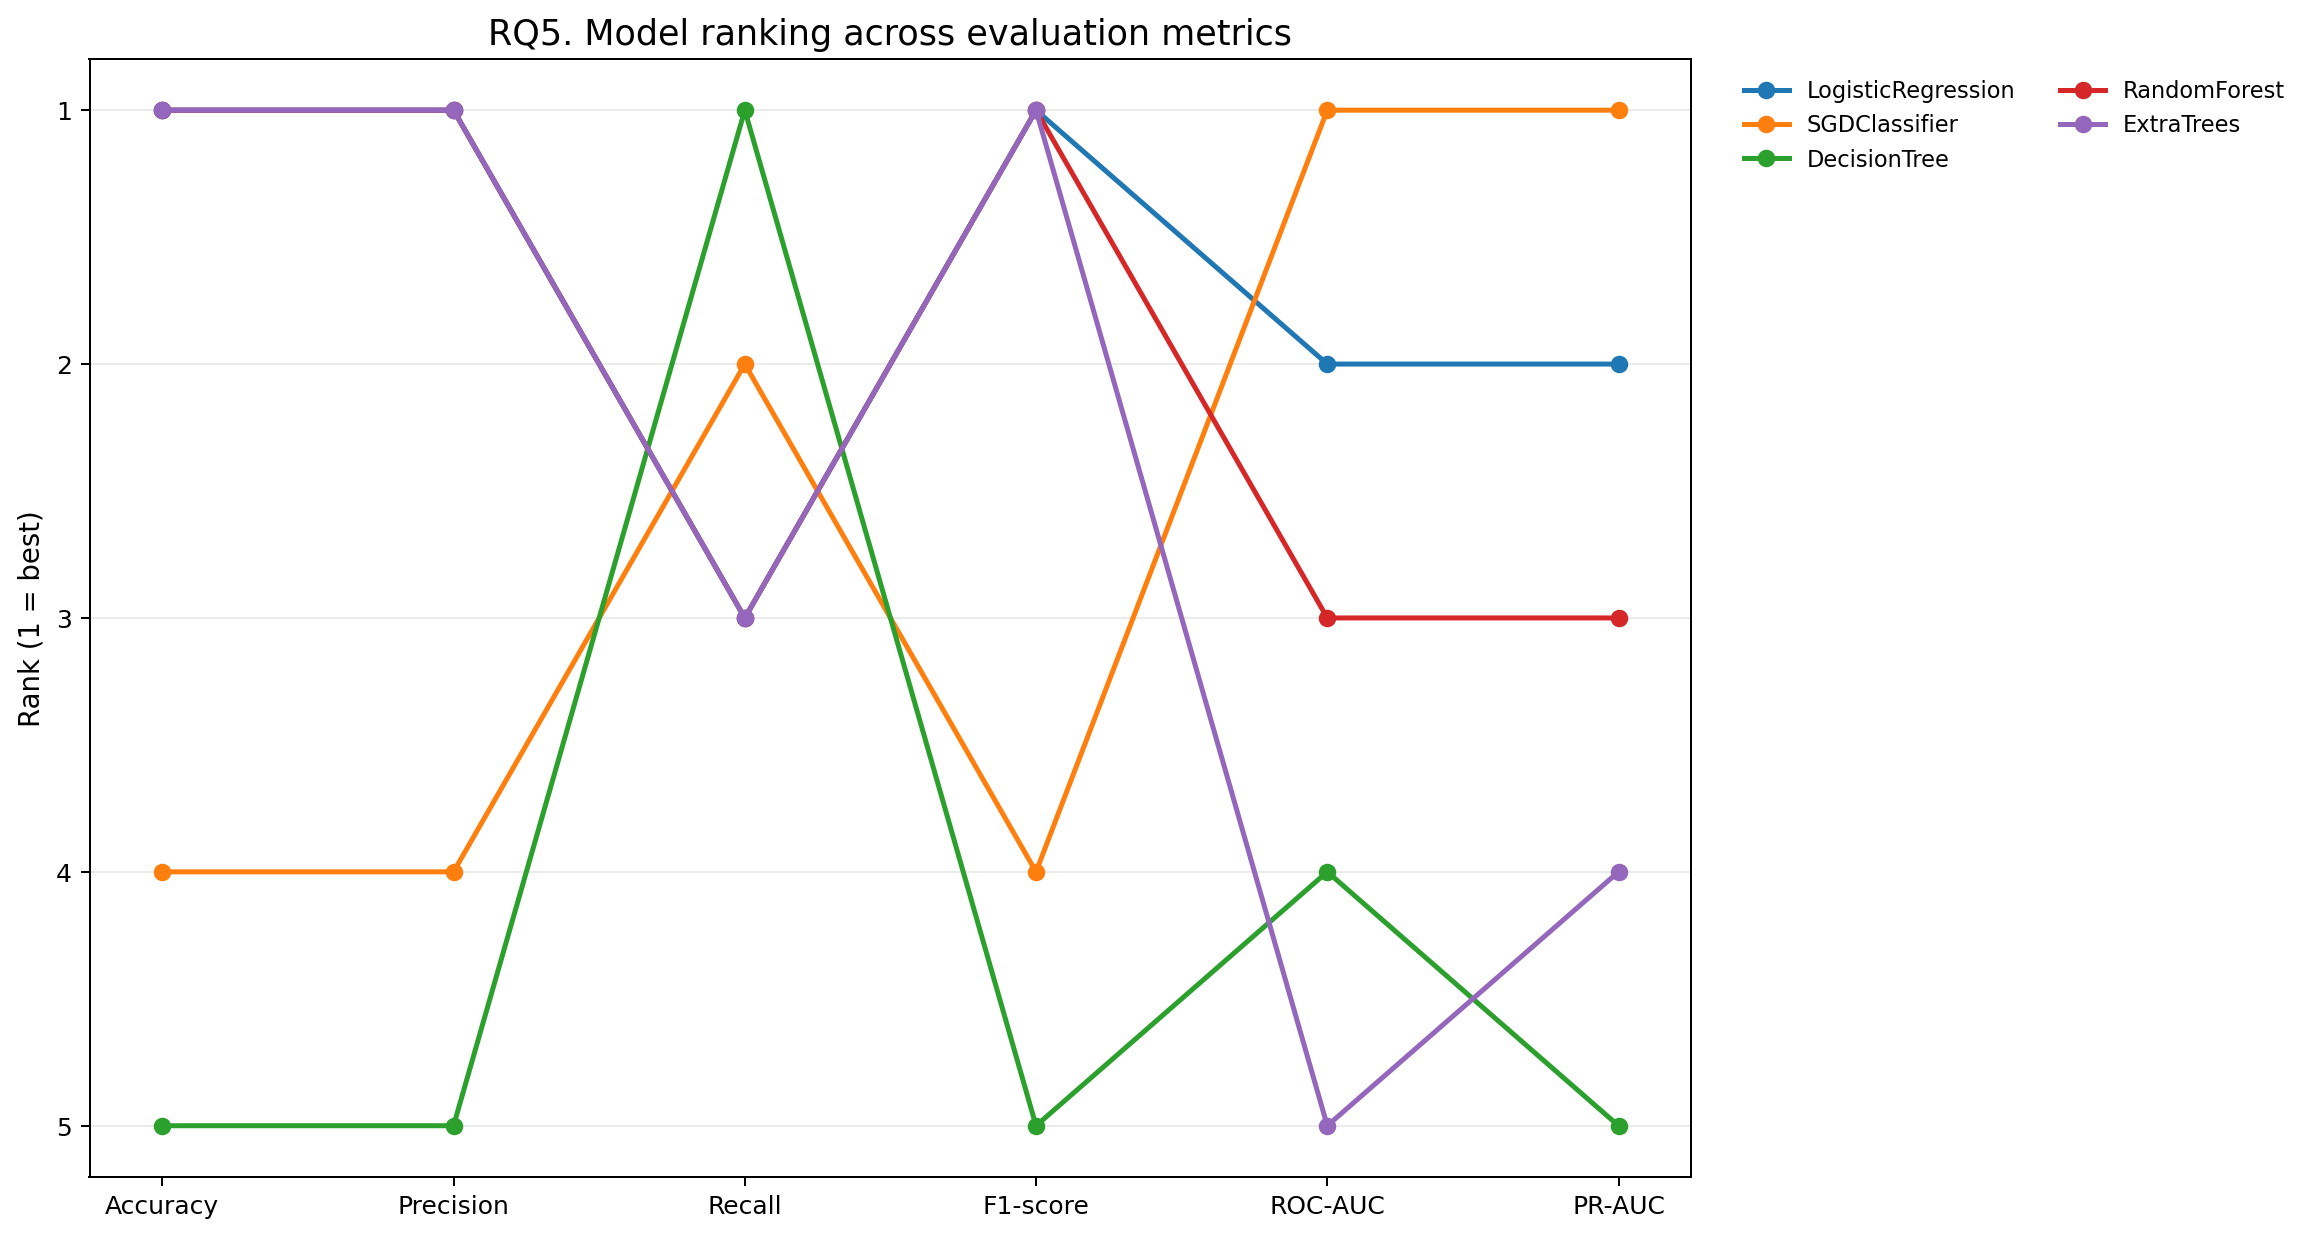

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,Rank_Accuracy,Rank_Precision,Rank_Recall,Rank_F1-score,Rank_ROC-AUC,Rank_PR-AUC
0,LogisticRegression,0.840575,1.000000,0.556432,0.715010,0.779354,0.788518,1,1,3,1,2,2
4,ExtraTrees,0.840575,1.000000,0.556432,0.715010,0.777310,0.786814,1,1,3,1,5,4
3,RandomForest,0.840575,1.000000,0.556432,0.715010,0.778737,0.788177,1,1,3,1,3,3
1,SGDClassifier,0.838225,0.984840,0.558491,0.712775,0.779558,0.788614,4,4,2,4,1,1
2,DecisionTree,0.830845,0.940091,0.565391,0.706111,0.778261,0.784980,5,5,1,5,4,5


In [5]:

# RQ5: Sensitivity to evaluation metrics
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

preprocessor = make_preprocessor(X_train_small, scale_numeric=True)

models = {
    "LogisticRegression": LogisticRegression(max_iter=250, solver="saga", n_jobs=-1, class_weight="balanced"),
    "SGDClassifier": SGDClassifier(loss="log_loss", max_iter=2500, tol=1e-3, class_weight="balanced", random_state=42),
    "DecisionTree": DecisionTreeClassifier(max_depth=12, min_samples_leaf=50, class_weight="balanced", random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=120, max_depth=14, n_jobs=-1, class_weight="balanced_subsample", random_state=42),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=160, max_depth=16, n_jobs=-1, class_weight="balanced", random_state=42),
}

rows = []
for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    pipe.fit(X_train_small, y_train_small)
    m, _ = eval_clf(pipe, X_test, y_test)
    rows.append({"Model": name, **m})

table = pd.DataFrame(rows)

metric_cols = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]
for col in metric_cols:
    table[f"Rank_{col}"] = table[col].rank(ascending=False, method="min").astype(int)

save_table(table, "RQ5_table_metric_sensitivity.csv")

# Bump/slope-style plot for ranks across metrics
fig, ax = plt.subplots(figsize=(13, 7))
x = np.arange(len(metric_cols))
for _, row in table.iterrows():
    ranks = [row[f"Rank_{m}"] for m in metric_cols]
    ax.plot(x, ranks, marker="o", linewidth=2, label=row["Model"])
ax.set_xticks(x)
ax.set_xticklabels(metric_cols, rotation=0)
ax.set_yticks(range(1, len(table) + 1))
ax.invert_yaxis()
ax.set_ylabel("Rank (1 = best)")
ax.set_title("RQ5. Model ranking across evaluation metrics")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False, ncol=2, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
save_fig_pdf(fig, "RQ5_figure_metric_sensitivity.pdf")
plt.show()

display(table.sort_values("F1-score", ascending=False))
